In [1]:
!pip install algs4
!pip install matplotlib
!pip install powerlaw
# O grafo $G = (V, E) é um grafo direcionado (digraph) onde 
# V representa os usuários da Wikipédia 
# E representa os votos de um usuário para outro


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\caiop\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\caiop\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\caiop\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [ ]:
from algs4.symbol_digraph import SymbolDigraph
from algs4.digraph import Digraph

import matplotlib.pyplot as plt
import numpy as np
import powerlaw

# wiki_vote_teste
sg = SymbolDigraph("Wiki-Vote.txt","\t")
graph = sg.digraph()

V = graph.V
E = graph.E

# G.adj é uma lista de objetos Bag. Para obter o tamanho, usamos o método .size()
outdegrees = [graph.adj[v].size() for v in range(V)]


indegrees = [0] * V

for v in range(V):
  for w in graph.adj[v]: # w são os vizinhos de saída de v
    indegrees[w] += 1

# 2. Cálculo das Métricas Básicas
densidade = E / (V * (V - 1)) if V > 1 else 0
medium_degree = E / V if V > 0 else 0
total_degrees = [indegrees[v] + outdegrees[v] for v in range(V)]
max_outdegree = max(outdegrees)
max_indegree = max(indegrees)

def countDegreeNull(x):
    cnt = 0
    for c in x:
        if(c==0):
            cnt+=1
    return cnt
       
print("Vértices:",V)
print("Arestas:", E)
print("Grau médio:", round(medium_degree, 2))
print("Densidade:", round(densidade, 6))
print("Vertices sem grau", countDegreeNull(total_degrees))
print("vertices sem grau de saida",countDegreeNull(outdegrees)) 
print("vertices sem grau de entrada",countDegreeNull(indegrees)) 
print("Grau maximo de saida:", max_outdegree)
print("Grau maximo de entrada:", max_indegree)


Vértices: 7115
Arestas: 103689
Grau médio: 14.57
Densidade: 0.002049
Vertices sem grau 0
vertices sem grau de saida 1005
vertices sem grau de entrada 4734
Grau maximo de saida: 893
Grau maximo de entrada: 457


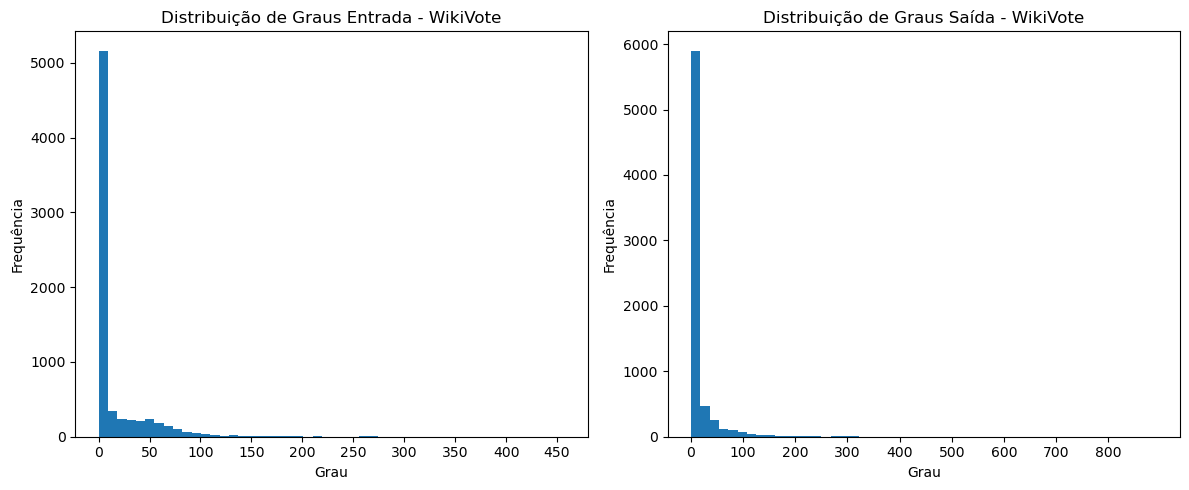

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))
# Graus de entrada
axs[0].hist(indegrees, bins=50)
axs[0].set_xticks(np.arange(0, max(indegrees)+1, 50))
axs[0].set_xlabel("Grau")
axs[0].set_ylabel("Frequência")
axs[0].set_title("Distribuição de Graus Entrada - WikiVote")

# Graus de saída
axs[1].hist(outdegrees, bins=50)
axs[1].set_xticks(np.arange(0, max(outdegrees)+1, 100))
axs[1].set_xlabel("Grau")
axs[1].set_ylabel("Frequência")
axs[1].set_title("Distribuição de Graus Saída - WikiVote")

plt.tight_layout()
plt.show()


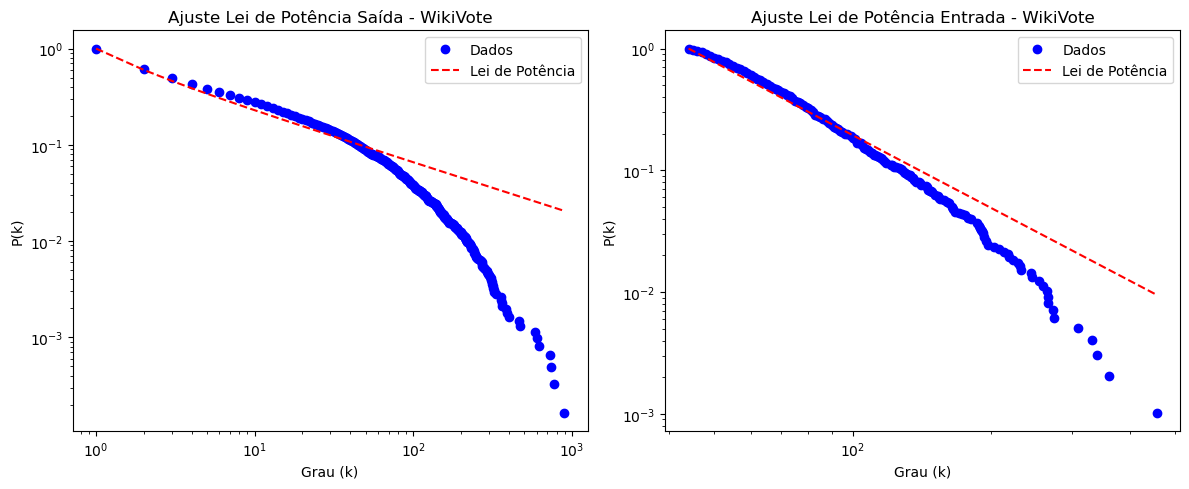

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Entrada
fitOut = powerlaw.Fit(outdegrees, discrete=True,verbose=False)
fitOut.plot_ccdf(ax=axs[0], color='blue', marker='o', linestyle='None', label='Dados')
fitOut.power_law.plot_ccdf(ax=axs[0], color='red', linestyle='--', label='Lei de Potência')
axs[0].set_xlabel("Grau (k)")
axs[0].set_ylabel("P(k)")
axs[0].set_title("Ajuste Lei de Potência Saída - WikiVote")
axs[0].legend()

# Saída
fitIn = powerlaw.Fit(indegrees, discrete=True,verbose=False)
fitIn.plot_ccdf(ax=axs[1], color='blue', marker='o', linestyle='None', label='Dados')
fitIn.power_law.plot_ccdf(ax=axs[1], color='red', linestyle='--', label='Lei de Potência')
axs[1].set_xlabel("Grau (k)")
axs[1].set_ylabel("P(k)")
axs[1].set_title("Ajuste Lei de Potência Entrada - WikiVote")
axs[1].legend()

plt.tight_layout()
plt.show()

In [5]:
print("Alpha outdegrees :", fitOut.power_law.alpha) # >2 a <3 segue lei de potencia
print("xmin outdegrees", fitOut.power_law.xmin) # segue a lei para vertices com grau >= 107

print("Alpha indegrees:", fitIn.power_law.alpha) # <2 não segue lei de potencia
print("xmin indegrees", fitIn.power_law.xmin) # vertices a partir de grau 20

Alpha outdegrees : 1.5299660828606068
xmin outdegrees 1.0
Alpha indegrees: 2.9805102629586657
xmin indegrees 44.0
